# Explore here

In [1]:
# Your code here

In [2]:
cd /workspaces/imagenesclas.Rhonalmendoza/data/raw


/workspaces/imagenesclas.Rhonalmendoza/data/raw


In [3]:
DATA_PATH = "/workspaces/imagenesclas.Rhonalmendoza/data/train"
print("Ruta actual:", DATA_PATH)


Ruta actual: /workspaces/imagenesclas.Rhonalmendoza/data/train


In [4]:
! pip install tensorflow==2.12


Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
  Using cached scipy-1.17.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.1 MB)
  Using cached scipy-1.16.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.9 MB)
  Using cached scipy-1.16.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.9 MB)
  Using cached scipy-1.16.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.4 MB)
  Using cached scipy-1.16.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.3 MB)
  Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are ins

Importamos

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


2026-05-01 07:39:57.009189: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 07:40:00.730913: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 07:40:07.610935: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 07:40:07.612901: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-01 07:40:18.287166: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

2.12.0


VISUALIZACIÓN DE 9 PERROS Y 9 GATOS

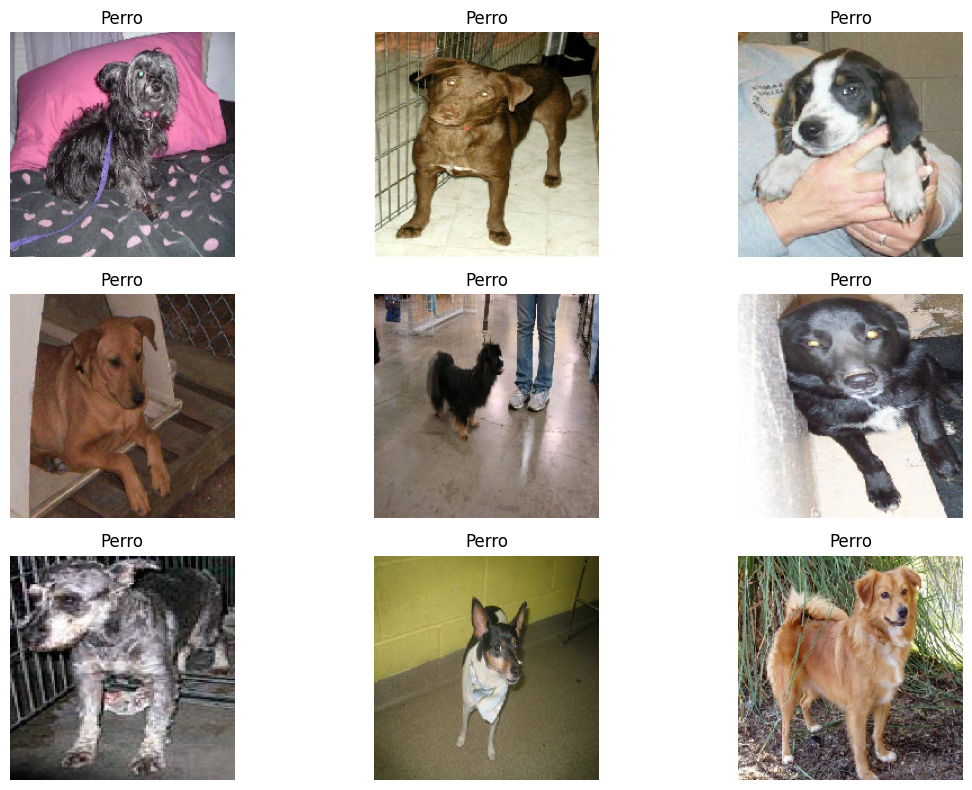

In [6]:
data_dir = "/workspaces/imagenesclas.Rhonalmendoza/data/train"
dogs_dir = os.path.join(data_dir, "dog")

lista_imagenes_dog = sorted([f for f in os.listdir(dogs_dir) if f.endswith(".jpg")])

imagenes_dog = []
for i in range(9):
    img_path = os.path.join(dogs_dir, lista_imagenes_dog[i])
    img = image.load_img(img_path, target_size=(200,200))
    img_array = image.img_to_array(img) / 255.0
    imagenes_dog.append(img_array)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagenes_dog[i])
    plt.title("Perro")
    plt.axis("off")

plt.tight_layout()
plt.show()

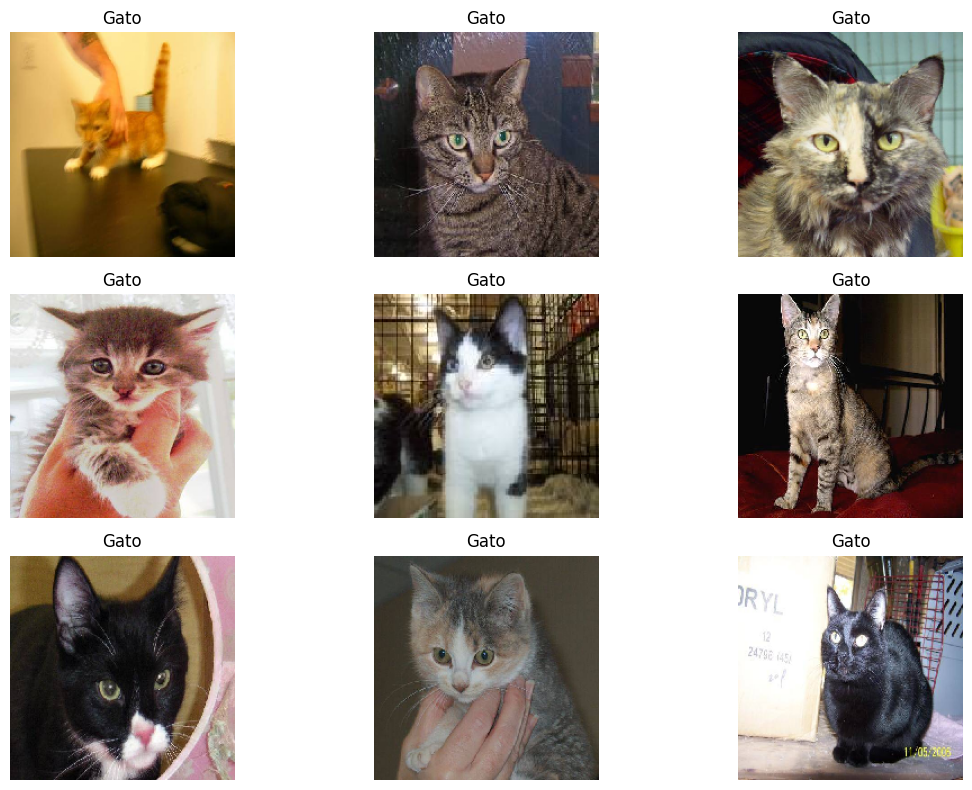

In [7]:
cats_dir = os.path.join(data_dir, "cat")

lista_imagenes_cat = sorted([f for f in os.listdir(cats_dir) if f.endswith(".jpg")])

imagenes_cat = []
for i in range(9):
    img_path = os.path.join(cats_dir, lista_imagenes_cat[i])
    img = image.load_img(img_path, target_size=(200,200))
    img_array = image.img_to_array(img) / 255.0
    imagenes_cat.append(img_array)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagenes_cat[i])
    plt.title("Gato")
    plt.axis("off")

plt.tight_layout()
plt.show()


GENERADORES DE DATOS

In [8]:
image_size = (200, 200)

datagentrain = ImageDataGenerator(rescale=1./255)
datagentest = ImageDataGenerator(rescale=1./255)

train_data = datagentrain.flow_from_directory(
    "/workspaces/imagenesclas.Rhonalmendoza/data/train",
    target_size=image_size,
    batch_size=32,
    class_mode='binary'
)

test_data = datagentest.flow_from_directory(
    "/workspaces/imagenesclas.Rhonalmendoza/data/test",
    target_size=image_size,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(200,200,3)))
model.add(MaxPool2D(2))

model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(MaxPool2D(2))

model.add(Conv2D(96, (3,3), activation="relu", padding="same"))
model.add(MaxPool2D(2))

model.add(GlobalAveragePooling2D())

model.add(Dense(64, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 200, 200, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 100, 100, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 100, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 50, 50, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 50, 50, 96)        55392     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 25, 25, 96)       0

In [6]:
direccion_guardado = "/workspaces/imagenesclas.Rhonalmendoza/models"
os.makedirs(direccion_guardado, exist_ok=True)

print("Carpeta de guardado:", direccion_guardado)

Carpeta de guardado: /workspaces/imagenesclas.Rhonalmendoza/models


In [8]:
checkpoint_path = os.path.join(direccion_guardado, "best_dog_cat_model.keras")

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

ENTRENAMIENTO

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[checkpoint, early]
)


Epoch 1/10


2026-05-01 05:39:30.107215: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


704/704 [==============================] - ETA: 0s - loss: 0.6521 - accuracy: 0.5964

2026-05-01 05:49:10.894279: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



Epoch 1: val_accuracy improved from -inf to 0.64520, saving model to /workspaces/imagenesclas.Rhonalmendoza/models/best_dog_cat_model.keras
704/704 [==============================] - 600s 843ms/step - loss: 0.6521 - accuracy: 0.5964 - val_loss: 0.6185 - val_accuracy: 0.6452
Epoch 2/10
704/704 [==============================] - ETA: 0s - loss: 0.5972 - accuracy: 0.6759

MODELO VGG16

In [4]:
model = Sequential()

model.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
model.add(Conv2D(32, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2)))

model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dense(2, activation="softmax"))

model.compile(optimizer=Adam(1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                    

In [7]:
final_model_path = os.path.join(direccion_guardado, "final_dog_cat_model.keras")
model.save(final_model_path)

print("Modelo guardado exitosamente en:", final_model_path)


Modelo guardado exitosamente en: /workspaces/imagenesclas.Rhonalmendoza/models/final_dog_cat_model.keras
